# Rectified flow

https://arxiv.org/pdf/2209.03003

Let's get nearer form the SOTA algoithms

In [116]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

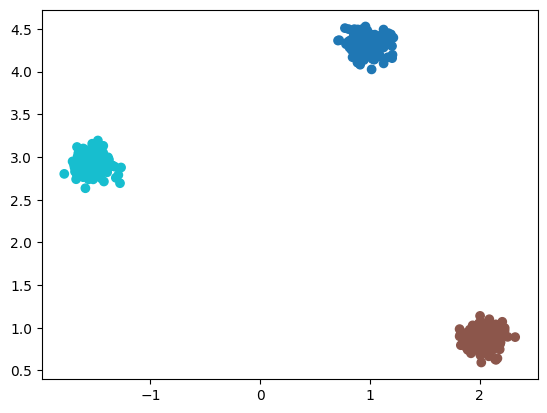

In [117]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=500, centers=3, cluster_std=0.1, n_features=2,
                  random_state=0)
X.shape
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10" )

In [301]:
# # noisy = X[y==0]
# # data = X[y!=0]
# noisy.shape
# plt.scatter(data[:, 0], data[:, 1])

In [318]:
class recti(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_emb = nn.Sequential(
            nn.Linear(1, 16),
            nn.SiLU(),
        )
        self.net = nn.Sequential(
            nn.Linear(2 + 16, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        xt = torch.cat([x, t_emb], dim=-1)
        return self.net(xt)
        



In [319]:
# x = torch.randn((5,2))
# t = torch.randn(5,1)
# modtest = recti()
# modtest(x,t).shape

In [320]:
torch.rand(4,1)

tensor([[0.5458],
        [0.9788],
        [0.9316],
        [0.7003]])

In [321]:
from torch.utils.data import Dataset, DataLoader
class rataset(Dataset):
    def __init__(self, input, target, nb):
        self.input = input
        self.target = target
        self.nb = nb
    
    def __len__(self):
        return self.nb
    def __getitem__(self, _):
        i0 = torch.randint(0, len(self.input), ()).item()
        i1 = torch.randint(0, len(self.target), ()).item()
        return self.input[i0], self.target[i1]

noisy_t = torch.randn((len(X), 2)) 
data_t  = torch.from_numpy(X).float()

batch_size = 32

data_f = rataset(noisy_t, data_t, nb=500)
loader = DataLoader(data_f, batch_size=batch_size, shuffle=False, drop_last=True)

L = E[ ||v(x_t, t) - (x_1 - x_0)||² ]


## Training

loss:1.9680061340332031 at epoch 0
loss:1.4838486909866333 at epoch 100
loss:1.5761919021606445 at epoch 200


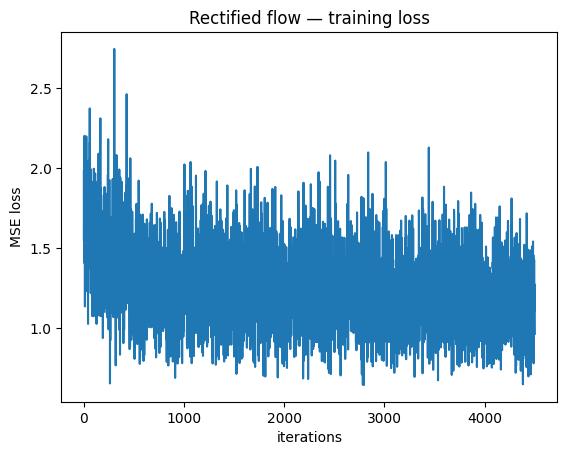

In [322]:
model = recti()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epoch = 300

losses = []
def train_loop(mod, opt, dataloader):
    mod.train()
    for _, (x0, x1) in enumerate(dataloader):
        t = torch.rand(batch_size, 1)
        x0 = torch.randn(batch_size, 2) 
        xt = t * x1 + (1-t) * x0
        pred_v = mod(xt, t)
        loss = F.mse_loss(x1-x0, pred_v)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    
for ep in range(epoch):
    train_loop(model, optimizer, loader)
    if ep%100==0:
        print(f"loss:{losses[-1]} at epoch {ep}")

plt.plot(losses)
plt.xlabel("iterations")
plt.ylabel("MSE loss")
plt.title("Rectified flow — training loss")
plt.show()

## Sampling without reflow

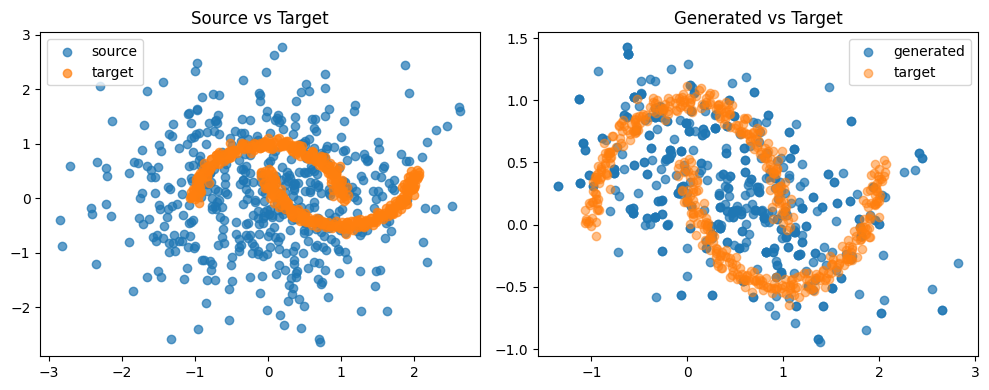

In [323]:
@torch.no_grad()
def sample(mod, n_samples=500, n_steps=50):
    mod.eval()
    idx = torch.randint(0, len(noisy_t), (n_samples,))
    x = noisy_t[idx].clone()
    dt = 1.0 / n_steps
    way = [x[:10].numpy()]
    for i in range(n_steps):
        t = torch.full((n_samples, 1), i * dt)
        x = x + mod(x, t) * dt
        way.append(x[:10].numpy())
    return x.numpy()  , way

generated, way  = sample(model)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(noisy_t[:, 0], noisy_t[:, 1], label="source", alpha=0.7)
axes[0].scatter(data_t[:, 0],  data_t[:, 1],  label="target", alpha=0.7)
axes[0].legend()
axes[0].set_title("Source vs Target")

axes[1].scatter(generated[:, 0], generated[:, 1], label="generated", alpha=0.7)
axes[1].scatter(data_t[:, 0],      data_t[:, 1],      label="target",    alpha=0.5)
axes[1].legend()
axes[1].set_title("Generated vs Target")
plt.tight_layout()
plt.show()


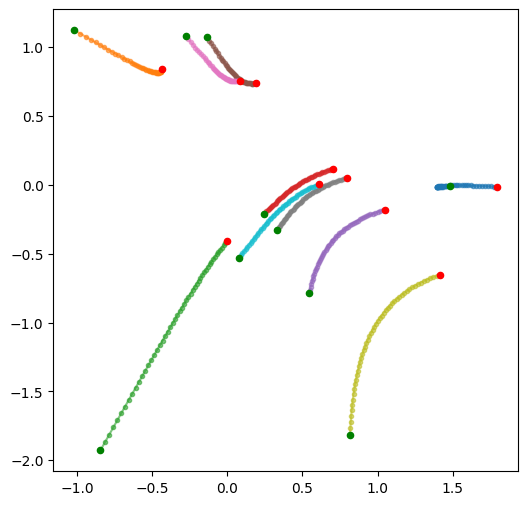

In [324]:
way_arr = np.array(way)  # shape (n_steps+1, 10, 2)

fig, ax = plt.subplots(figsize=(6, 6))
for i in range(10):
    traj = way_arr[:, i, :]          # shape (n_steps+1, 2)
    ax.plot(traj[:, 0], traj[:, 1], '-o', alpha=0.6, markersize=3)
    ax.scatter(traj[0, 0], traj[0, 1], color='green', zorder=5, s=20)
    ax.scatter(traj[-1, 0], traj[-1, 1], color='red', zorder=5, s=20)
plt.show()


## Interpretation of the trajectories
Here the trajectories cross, because we're not plotting the (x,t) space, but the x space. The trajectories can cross in the x-space. Let's see the (x,t) space now:

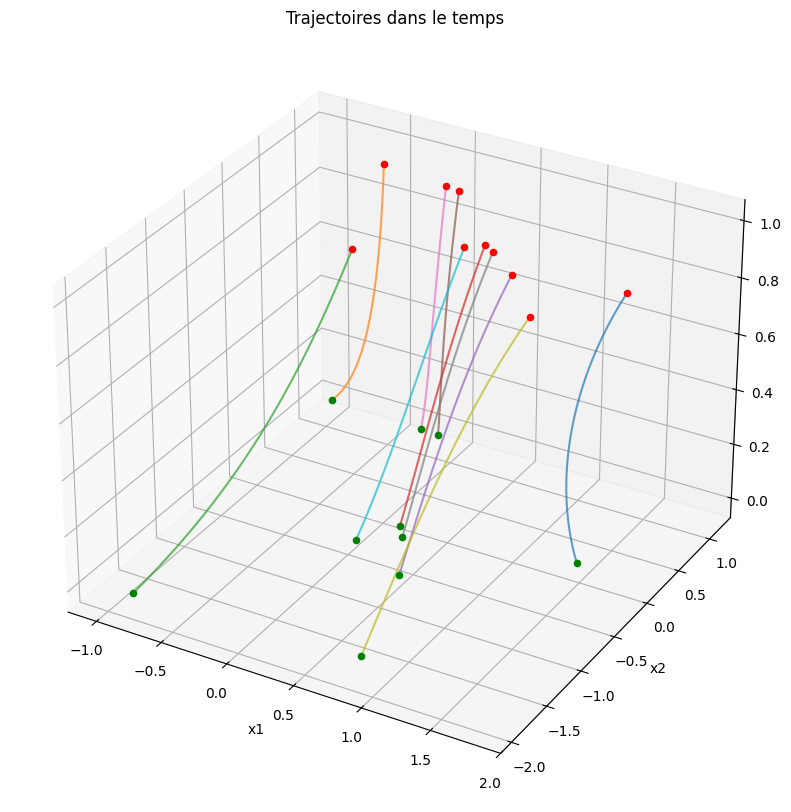

In [325]:
from mpl_toolkits.mplot3d import Axes3D

way_arr = np.array(way)  # (n_steps+1, 10, 2)
n_steps = len(way_arr) - 1
times = np.linspace(0, 1, n_steps + 1)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for i in range(10):
    ax.plot(way_arr[:, i, 0], way_arr[:, i, 1], times, alpha=0.7)
    ax.scatter(*way_arr[0, i, :], times[0], color='green', s=20, zorder=5)
    ax.scatter(*way_arr[-1, i, :], times[-1], color='red', s=20, zorder=5)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('t')
ax.set_title('Trajectoires dans le temps')
plt.show()


In [326]:
import plotly.graph_objects as go

fig = go.Figure()
for i in range(10):
    fig.add_trace(go.Scatter3d(
        x=way_arr[:, i, 0], y=way_arr[:, i, 1], z=times,
        mode='lines+markers',
        marker=dict(size=2),
        line=dict(width=3)
    ))
fig.update_layout(scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='t'))
fig.show()


## REFLOW

In [327]:
@torch.no_grad()
def sample(mod, x0, n_steps=50):
    mod.eval()
    x = x0.clone()
    dt = 1.0 / n_steps
    for i in range(n_steps):
        t = torch.full((len(x), 1), i * dt)
        x = x + mod(x, t) * dt
    return x

In [328]:
n_reflow = 3
steps = [50, 10, 5]

for n in range(n_reflow):
    with torch.no_grad():
        x0_all = noisy_t
        generated = torch.tensor(sample(model, noisy_t, n_steps=steps[n]))
    
    data_reflow = TensorDataset(x0_all, generated)
    load = DataLoader(data_reflow, batch_size=batch_size, shuffle=True, drop_last=True)
    losses = []
    def train_loop(mod, opt, dataloader, ep, n):
        mod.train()
        for _, (x0, x1) in enumerate(dataloader):
            t = torch.rand(batch_size, 1)
            xt = t * x1 + (1-t) * x0
            pred_v = mod(xt, t)
            loss = F.mse_loss(x1-x0, pred_v)
            opt.zero_grad()
            loss.backward()
            opt.step()
        if ep%20==0:
            print(f"loss:{loss.item()} at epoch {ep} reflow {n}")
    for ep in range(epoch):
        train_loop(model, optimizer, load, ep, n)

/tmp/ipykernel_1423/3732048476.py:7: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



loss:0.1109563559293747 at epoch 0 reflow 0
loss:0.05201403796672821 at epoch 20 reflow 0
loss:0.042871784418821335 at epoch 40 reflow 0
loss:0.028808899223804474 at epoch 60 reflow 0
loss:0.015253293327987194 at epoch 80 reflow 0
loss:0.032805293798446655 at epoch 100 reflow 0
loss:0.023337744176387787 at epoch 120 reflow 0
loss:0.01564985327422619 at epoch 140 reflow 0
loss:0.005479483865201473 at epoch 160 reflow 0
loss:0.016422422602772713 at epoch 180 reflow 0
loss:0.011642892844974995 at epoch 200 reflow 0
loss:0.008033440448343754 at epoch 220 reflow 0
loss:0.004882999695837498 at epoch 240 reflow 0
loss:0.004027435090392828 at epoch 260 reflow 0
loss:0.003180392784997821 at epoch 280 reflow 0
loss:0.001376428292132914 at epoch 0 reflow 1
loss:0.0007016461458988488 at epoch 20 reflow 1
loss:0.0004059355123899877 at epoch 40 reflow 1
loss:0.0007516596233472228 at epoch 60 reflow 1
loss:0.00033887726021930575 at epoch 80 reflow 1
loss:0.0006348425522446632 at epoch 100 reflow 1
lo

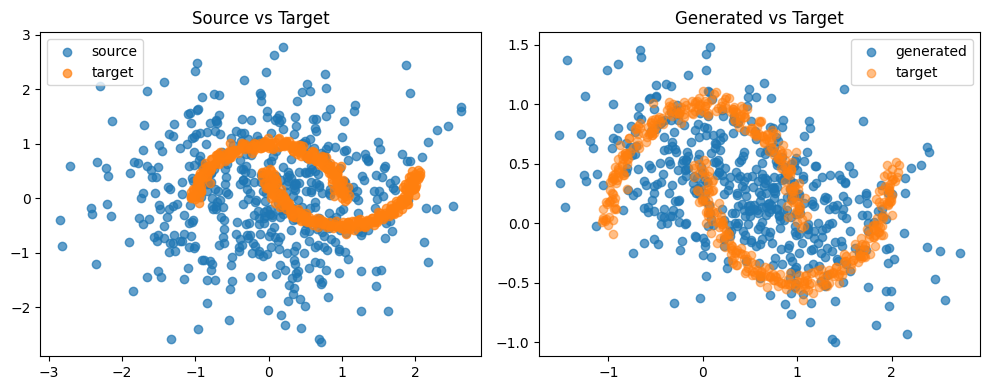

In [329]:
generated = sample(model, noisy_t, n_steps=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(noisy_t[:, 0], noisy_t[:, 1], label="source", alpha=0.7)
axes[0].scatter(data_t[:, 0],  data_t[:, 1],  label="target", alpha=0.7)
axes[0].legend()
axes[0].set_title("Source vs Target")

axes[1].scatter(generated[:, 0], generated[:, 1], label="generated", alpha=0.7)
axes[1].scatter(data_t[:, 0],      data_t[:, 1],      label="target",    alpha=0.5)
axes[1].legend()
axes[1].set_title("Generated vs Target")
plt.tight_layout()
plt.show()
s